# The MOT failure model, stage by stage

A hands-on walkthrough of the model that runs behind **Check your car**. Every stage has a plot, and most have a **Try this** prompt: change something, rerun the cell, and see what moves.

The notebook imports the real pipeline (`config.py`, `scoring.py` and `models/model_v1.json`), so what you explore here is exactly what's deployed. It changes nothing: it only reads.

**Stages**
1. The data, and one car's history
2. The target, and drift over time
3. Features one at a time
4. A trap: Simpson's paradox
5. Redundancy between features
6. Fitting the model
7. From scores to ranking: the ROC curve and AUC
8. Calibration
9. Risk bands
10. Segments
11. One car, end to end
12. Exercises

**Before you start:** the SSD must be plugged in, `data/processed/training_all.csv` must exist (built by `build_training_all`), and the notebook needs your environment as its kernel.

In [1]:
# Setup: find the repository root, so the pipeline's own modules can be imported
import os, sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

from config import TRAINING_ALL_CSV, VALIDATION_START, TEST_START
from pipeline.failure_model.scoring import (NUMERIC, design_matrix, raw_logit,
                                            probability, band, age_key)

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 160)

model = json.loads((ROOT / "models" / "model_v1.json").read_text())
df = pd.read_csv(TRAINING_ALL_CSV, dtype={"make": str})
df["year"] = df["test_date"].str[:4].astype(int)

train = df[df["test_date"] < VALIDATION_START].copy()
val = df[(df["test_date"] >= VALIDATION_START) & (df["test_date"] < TEST_START)].copy()
test = df[df["test_date"] >= TEST_START].copy()
print(f"{len(df):,} test cycles  |  train {len(train):,}  validation {len(val):,}  test {len(test):,}")

495,116 test cycles  |  train 286,489  validation 66,836  test 141,791


In [2]:
for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:<10} {part['test_date'].min()} to {part['test_date'].max()}")

train      2018-05-20 to 2022-12-31
validation 2023-01-02 to 2023-12-31
test       2024-01-01 to 2026-02-04


## 1. The data, and one car's history

One row of the training table is one **test cycle**: a car's first MOT in a given year, with everything known *before* it. Look at a few rows first.

In [4]:
df.head(10)

,registration,mot_test_number,test_date,target_failed,make,fuel_type,age_years,n_prior_cycles,n_prior_fails,fails_last_3,prev_odometer,prev_fail_items,prev_advisories,days_since_prev,annual_miles_last_interval,year
0,0439JHZ,424080015680,2019-09-02,0,OPAL,DIESEL,3.96,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
1,0508LKH,114488511722,2024-12-19,0,MERCEDES-BENZ,PETROL,10.02,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
2,09L6317,573932871102,2019-08-14,1,CITROEN,DIESEL,9.91,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019
3,102D267,553426594168,2022-03-17,0,MERCEDES-BENZ,DIESEL,3.91,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4,102D267,978150425476,2025-02-19,1,MERCEDES-BENZ,DIESEL,6.84,1,0.0,0.0,69009.0,0.0,0.0,1070.0,NaN,2025
5,103XWE,972215818067,2024-05-24,0,MG,PETROL,66.40,4,2.0,1.0,5798.0,0.0,0.0,3581.0,140.0,2024
6,103XWE,965554701363,2025-06-30,0,MG,PETROL,67.50,5,2.0,1.0,7541.0,0.0,0.0,402.0,178.0,2025
7,106GC,382390977233,2022-11-18,0,LAND ROVER,DIESEL,3.04,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
8,106GC,221175573201,2023-11-03,0,LAND ROVER,DIESEL,3.99,1,0.0,0.0,14324.0,0.0,0.0,350.0,NaN,2023
9,106GC,134982637137,2024-11-07,0,LAND ROVER,DIESEL,5.01,2,0.0,0.0,21944.0,0.0,0.0,370.0,7952.0,2024


In [26]:
hist = ["n_prior_fails", "fails_last_3", "prev_fail_items", "prev_advisories", "days_since_prev", "prev_odometer"]
blank = train[hist].isna()
print("Rows where n_prior_fails is blank:", blank["n_prior_fails"].sum())
print("...of which all six are blank:", blank[blank["n_prior_fails"]].all(axis=1).sum())
print("Rows with only prev_odometer blank:", (blank["prev_odometer"] & ~blank["n_prior_fails"]).sum())

Rows where n_prior_fails is blank: 25833
...of which all six are blank: 25833
Rows with only prev_odometer blank: 1724


In [27]:
rows = train.index[:5]
display(train.loc[rows, ["make"] + NUMERIC])        # before: raw features, with blanks
display(X.loc[rows, NUMERIC + ["no_history", "odometer_missing"]].round(3))   # after: filled and standardised

,make,age_years,n_prior_fails,fails_last_3,prev_odometer,prev_fail_items,prev_advisories,days_since_prev
0,OPAL,3.96,NaN,NaN,NaN,NaN,NaN,NaN
2,CITROEN,9.91,NaN,NaN,NaN,NaN,NaN,NaN
3,MERCEDES-BENZ,3.91,NaN,NaN,NaN,NaN,NaN,NaN
7,LAND ROVER,3.04,NaN,NaN,NaN,NaN,NaN,NaN
11,AUDI,4.90,0.0,0.0,7350.0,0.0,0.0,693.0


KeyError: '[0, 2, 3, 7] not in index'

Now one car, from the raw database to its training rows. Its tests are listed with the rule that turns them into cycles: a test within 60 days of the previous one is a **retest** and is dropped.

**Try this:** change `pick` to look at other cars, for example one with `n_prior_fails` of 3 or more.

In [12]:
from pipeline.common import connect_db

pick = df.loc[df["n_prior_fails"] >= 2, "registration"].iloc[2]   # a car with some history

con = connect_db()
raw = pd.read_sql(
    "SELECT completed_date, test_result, odometer_value, odometer_unit, data_source "
    "FROM mot_tests WHERE registration = ? ORDER BY completed_date", con, params=(pick,))
con.close()

raw["date"] = pd.to_datetime(raw["completed_date"].str[:10])
raw["days_since_previous"] = raw["date"].diff().dt.days
raw["kept_as_cycle"] = raw["days_since_previous"].isna() | (raw["days_since_previous"] > 60)
print(f"Raw MOT tests for {pick}:")
display(raw[["completed_date", "test_result", "odometer_value", "data_source",
             "days_since_previous", "kept_as_cycle"]])

rows = df[df["registration"] == pick].copy()
rows["set"] = np.select(
    [rows["test_date"] < VALIDATION_START, rows["test_date"] < TEST_START],
    ["train", "validation"], default="test")
print(f"\nIts rows in training_all.csv (one per cycle predicted), with the split each falls in:")
display(rows[["test_date", "set", "target_failed", "age_years", "n_prior_fails",
              "fails_last_3", "prev_odometer", "prev_advisories"]])

Raw MOT tests for 10VD:


,completed_date,test_result,odometer_value,data_source,days_since_previous,kept_as_cycle
0,2017-08-29T09:51:01.000Z,PASSED,6933,DVSA,NaN,True
1,2018-08-22T09:42:14.000Z,PASSED,8031,DVSA,358.0,True
2,2019-08-20T11:07:59.000Z,FAILED,9083,DVSA,363.0,True
3,2019-08-20T12:05:26.000Z,PASSED,9083,DVSA,0.0,False
4,2020-08-18T11:42:52.000Z,PASSED,9785,DVSA,364.0,True
5,2021-08-24T11:04:03.000Z,PASSED,10391,DVSA,371.0,True
6,2022-08-15T09:09:56.000Z,PASSED,11084,DVSA,356.0,True
7,2023-08-22T08:48:57.000Z,FAILED,11679,DVSA,372.0,True
8,2023-08-22T08:48:58.000Z,PASSED,11679,DVSA,0.0,False
9,2024-08-13T10:15:06.000Z,PASSED,12207,DVSA,357.0,True



Its rows in training_all.csv (one per cycle predicted), with the split each falls in:


,test_date,set,target_failed,age_years,n_prior_fails,fails_last_3,prev_odometer,prev_advisories
37,2018-08-22,train,0,3.95,0.0,0.0,6933.0,0.0
38,2019-08-20,train,1,4.95,0.0,0.0,8031.0,0.0
39,2020-08-18,train,0,5.94,1.0,1.0,9083.0,0.0
40,2021-08-24,train,0,6.96,1.0,1.0,9785.0,1.0
41,2022-08-15,train,0,7.93,1.0,1.0,10391.0,0.0
42,2023-08-22,validation,1,8.95,1.0,0.0,11084.0,0.0
43,2024-08-13,test,0,9.93,2.0,1.0,11679.0,0.0
44,2025-08-20,test,0,10.95,2.0,1.0,12207.0,0.0


Classic car exception below

In [13]:
from pipeline.common import connect_db

pick = df.loc[df["n_prior_fails"] >= 2, "registration"].iloc[0]   # a car with some history

con = connect_db()
raw = pd.read_sql(
    "SELECT completed_date, test_result, odometer_value, odometer_unit, data_source "
    "FROM mot_tests WHERE registration = ? ORDER BY completed_date", con, params=(pick,))
con.close()

raw["date"] = pd.to_datetime(raw["completed_date"].str[:10])
raw["days_since_previous"] = raw["date"].diff().dt.days
raw["kept_as_cycle"] = raw["days_since_previous"].isna() | (raw["days_since_previous"] > 60)
print(f"Raw MOT tests for {pick}:")
display(rows[["test_date", "set", "target_failed", "make", "age_years",
              "n_prior_fails", "fails_last_3", "prev_odometer",
              "prev_fail_items", "prev_advisories", "days_since_prev"]])

print(f"\nIts rows in the training table (one per cycle predicted):")
display(df[df["registration"] == pick][["test_date", "target_failed", "age_years", "n_prior_fails",
                                        "fails_last_3", "prev_odometer", "prev_advisories"]])

Raw MOT tests for 103XWE:


,test_date,set,target_failed,make,age_years,n_prior_fails,fails_last_3,prev_odometer,prev_fail_items,prev_advisories,days_since_prev
37,2018-08-22,train,0,MAZDA,3.95,0.0,0.0,6933.0,0.0,0.0,358.0
38,2019-08-20,train,1,MAZDA,4.95,0.0,0.0,8031.0,0.0,0.0,363.0
39,2020-08-18,train,0,MAZDA,5.94,1.0,1.0,9083.0,1.0,0.0,364.0
40,2021-08-24,train,0,MAZDA,6.96,1.0,1.0,9785.0,0.0,1.0,371.0
41,2022-08-15,train,0,MAZDA,7.93,1.0,1.0,10391.0,0.0,0.0,356.0
42,2023-08-22,validation,1,MAZDA,8.95,1.0,0.0,11084.0,0.0,0.0,372.0
43,2024-08-13,test,0,MAZDA,9.93,2.0,1.0,11679.0,1.0,0.0,357.0
44,2025-08-20,test,0,MAZDA,10.95,2.0,1.0,12207.0,0.0,0.0,372.0



Its rows in the training table (one per cycle predicted):


,test_date,target_failed,age_years,n_prior_fails,fails_last_3,prev_odometer,prev_advisories
5,2024-05-24,0,66.4,2.0,1.0,5798.0,0.0
6,2025-06-30,0,67.5,2.0,1.0,7541.0,0.0


## 2. The target, and drift over time

The target is `target_failed`: 1 if the test failed (including faults fixed on the spot), else 0. The fail rate falls over time, which is why the data is split by **date**, and why calibration matters later.

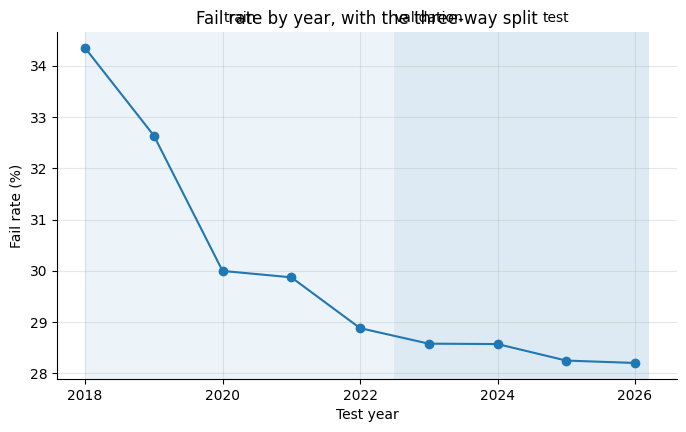

,mean,count
year,,
2018,0.343466,35430
2019,0.326381,60935
2020,0.299969,60423
2021,0.298720,63685
2022,0.288809,66016
2023,0.285774,66836
2024,0.285699,67473
2025,0.282477,67648
2026,0.282009,6670


In [15]:
by_year = df.groupby("year")["target_failed"].agg(["mean", "count"])
fig, ax = plt.subplots()
ax.plot(by_year.index, by_year["mean"] * 100, marker="o")
for start, end, label in [(2018, 2022.5, "train"), (2022.5, 2023.5, "validation"), (2023.5, 2026.2, "test")]:
    ax.axvspan(start, end, alpha=0.08 if label == "train" else 0.15)
    ax.text((start + end) / 2, by_year["mean"].max() * 100 + 0.5, label, ha="center")
ax.set(xlabel="Test year", ylabel="Fail rate (%)", title="Fail rate by year, with the three-way split")
plt.show()
by_year

## 3. Features one at a time

Before any model, check that each feature separates fails from passes on its own. Each panel bins a feature and plots the fail rate per bin (training data only). A steady rise is what a useful feature looks like.

**Try this:** add `"days_since_prev"` to `FEATS`, and say what its pattern means.

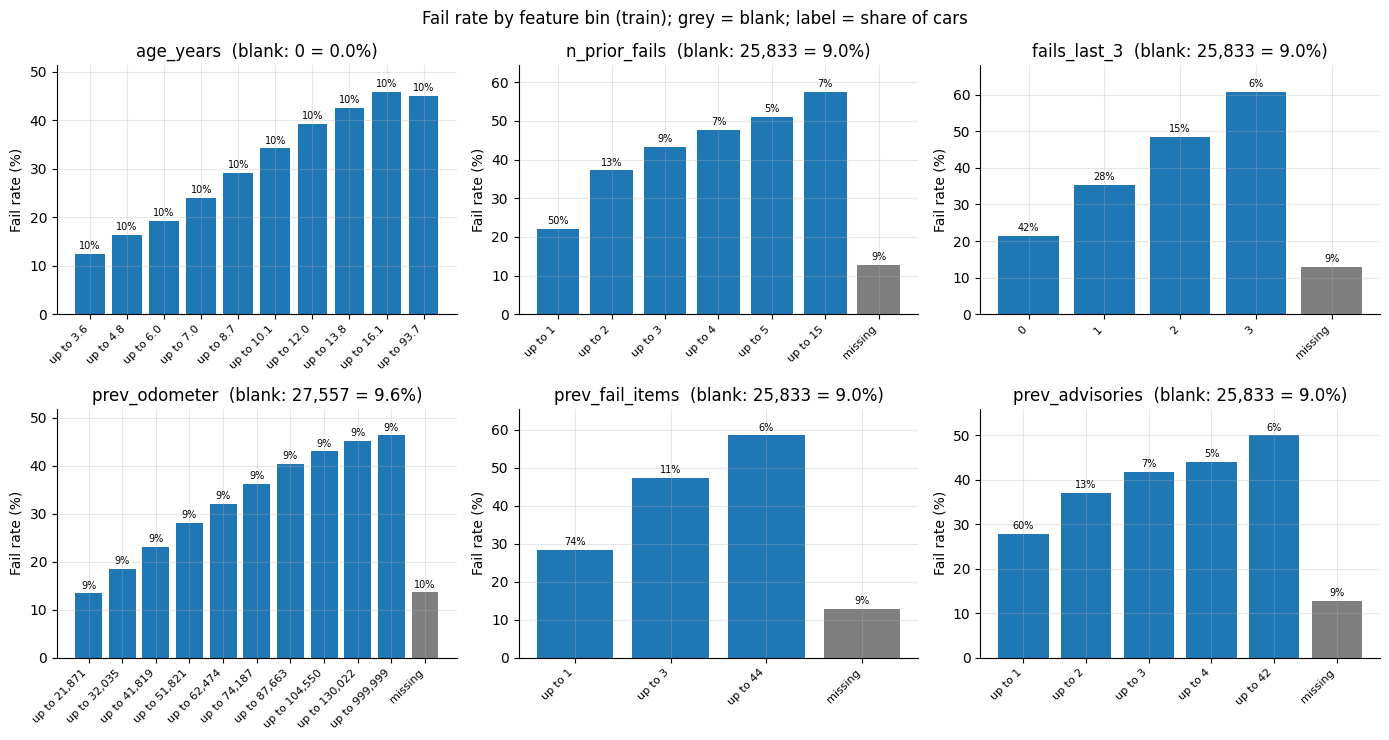

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, col in zip(axes.flat, FEATS):
    r = binned_rate(train, col)                           # no dropna: blanks are kept
    share = r["count"] / len(train) * 100                 # each bin's share of all training rows
    colours = ["tab:grey" if b == "missing" else "tab:blue" for b in r.index]
    bars = ax.bar(range(len(r)), r["mean"] * 100, color=colours)
    ax.bar_label(bars, labels=[f"{s:.0f}%" for s in share], fontsize=7, padding=2)
    ax.set_xticks(range(len(r)), r.index, rotation=45, ha="right", fontsize=8)
    n_missing = int(r.loc["missing", "count"]) if "missing" in r.index else 0
    ax.set(title=f"{col}  (blank: {n_missing:,} = {n_missing / len(train):.1%})", ylabel="Fail rate (%)")
    ax.margins(y=0.12)                                    # room for the labels above the bars
fig.suptitle("Fail rate by feature bin (train); grey = blank; label = share of cars")
fig.tight_layout(); plt.show()

## 4. A trap: Simpson's paradox

Comparing groups overall can point the wrong way when the groups differ on something else. Compare diesel and petrol overall, then within age bands.

Overall fail rate (%): {'DIESEL': 31.4, 'PETROL': 30.8}
Average age: {'DIESEL': 8.8, 'PETROL': 10.2}


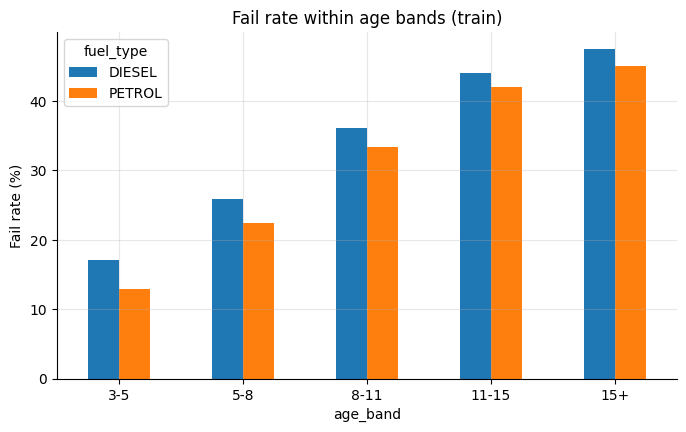

fuel_type,DIESEL,PETROL
age_band,,
3-5,17.0,12.9
5-8,25.9,22.4
8-11,36.1,33.3
11-15,44.0,42.0
15+,47.6,45.0


In [17]:
two = train[train["fuel_type"].isin(["DIESEL", "PETROL"])].copy()
two["age_band"] = pd.cut(two["age_years"], [0, 5, 8, 11, 15, 40], labels=["3-5", "5-8", "8-11", "11-15", "15+"])

overall = two.groupby("fuel_type")["target_failed"].mean() * 100
within = two.pivot_table(index="age_band", columns="fuel_type", values="target_failed", aggfunc="mean", observed=True) * 100
print("Overall fail rate (%):", overall.round(1).to_dict())
print("Average age:", two.groupby("fuel_type")["age_years"].mean().round(1).to_dict())

within.plot(kind="bar", rot=0, title="Fail rate within age bands (train)", ylabel="Fail rate (%)")
plt.show()
within.round(1)

If the overall comparison and the within-band comparison disagree, the overall one is confounded by age: one fuel's cars are older on average. That's why fuel type isn't in the model, while age is.

## 5. Redundancy between features

Two features that carry the same information make logistic regression's coefficients unstable. The heatmap shows pairwise rank correlation, and the VIF table shows how well each feature can be predicted from **all** the others: below 5 is fine.

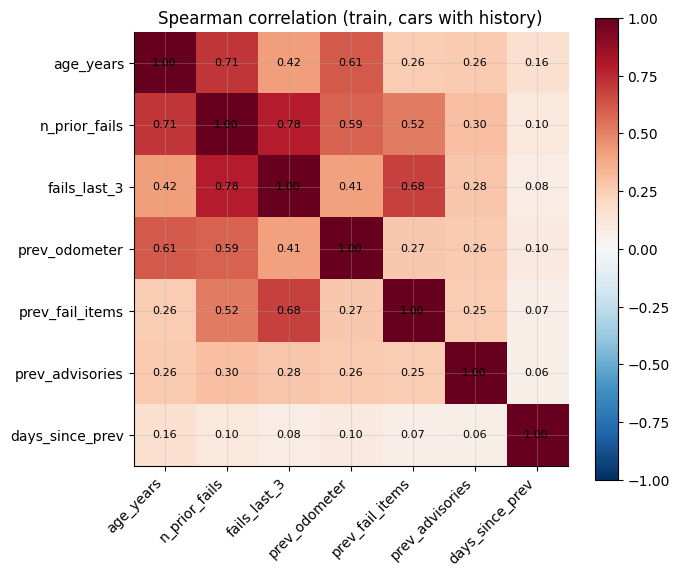

,VIF
n_prior_fails,3.33
fails_last_3,2.54
age_years,1.87
prev_fail_items,1.48
prev_odometer,1.43
prev_advisories,1.13
days_since_prev,1.05


In [18]:
X = train[NUMERIC].dropna()
corr = X.corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUMERIC)), NUMERIC, rotation=45, ha="right"); ax.set_yticks(range(len(NUMERIC)), NUMERIC)
for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Spearman correlation (train, cars with history)"); plt.show()

vif = {}
for f in NUMERIC:
    others = [c for c in NUMERIC if c != f]
    r2 = LinearRegression().fit(X[others], X[f]).score(X[others], X[f])
    vif[f] = 1 / (1 - r2)
pd.Series(vif, name="VIF").sort_values(ascending=False).round(2).to_frame()

## 6. Fitting the model

Refit the logistic regression on the training years, using `design_matrix` from `scoring.py`: the same transformation the deployed model uses (blanks filled, two flags, standardised numbers, 20 make columns). Then check the refit matches the saved `model_v1.json`. If it does, the deployed model is reproducible from the data.

array([[-1.03109196, -0.81825776, -0.83006434, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07711648, -0.81825776, -0.83006434, ...,  0.        ,
         0.        ,  0.        ],
       [-1.04040463, -0.81825776, -0.83006434, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.23410829, -0.81825776, -0.83006434, ...,  0.        ,
         0.        ,  0.        ],
       [-1.25087111, -0.81825776, -0.83006434, ...,  0.        ,
         0.        ,  0.        ],
       [ 7.3130657 ,  1.51180326,  1.37864777, ...,  0.        ,
         0.        ,  0.        ]])

Largest difference between saved and refitted coefficients: 6.54e-11


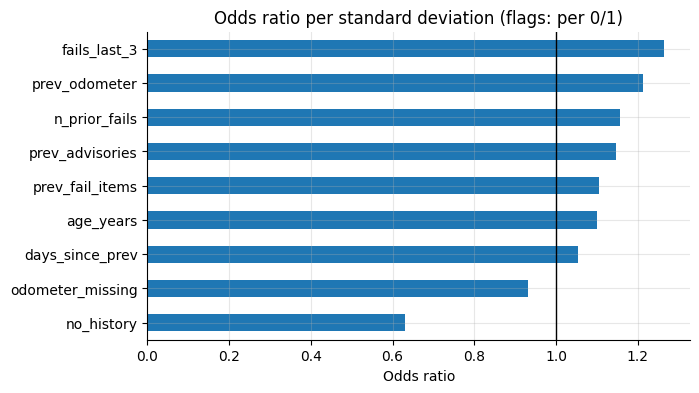

In [19]:
X_train = design_matrix(train, model)
refit = LogisticRegression(C=1.0, max_iter=5000).fit(X_train, train["target_failed"])

coefs = pd.DataFrame({"saved": model["coefficients"], "refit": refit.coef_[0]}, index=model["columns"])
print("Largest difference between saved and refitted coefficients:",
      f"{(coefs['saved'] - coefs['refit']).abs().max():.2e}")

numeric_part = coefs.loc[NUMERIC + ["no_history", "odometer_missing"], "saved"].sort_values()
ax = np.exp(numeric_part).plot(kind="barh", figsize=(7, 4), title="Odds ratio per standard deviation (flags: per 0/1)")
ax.axvline(1, color="black", lw=1); ax.set_xlabel("Odds ratio"); plt.show()

## 7. From scores to ranking: the ROC curve and AUC

The model gives every car a score. **AUC** asks: pick one car that failed and one that passed; how often does the failing car score higher? The histograms show the overlap that keeps AUC well below 1. Validation data only here.

**Try this:** compute the AUC of `age_years` alone with `roc_auc_score(val["target_failed"], val["age_years"])`, and compare.

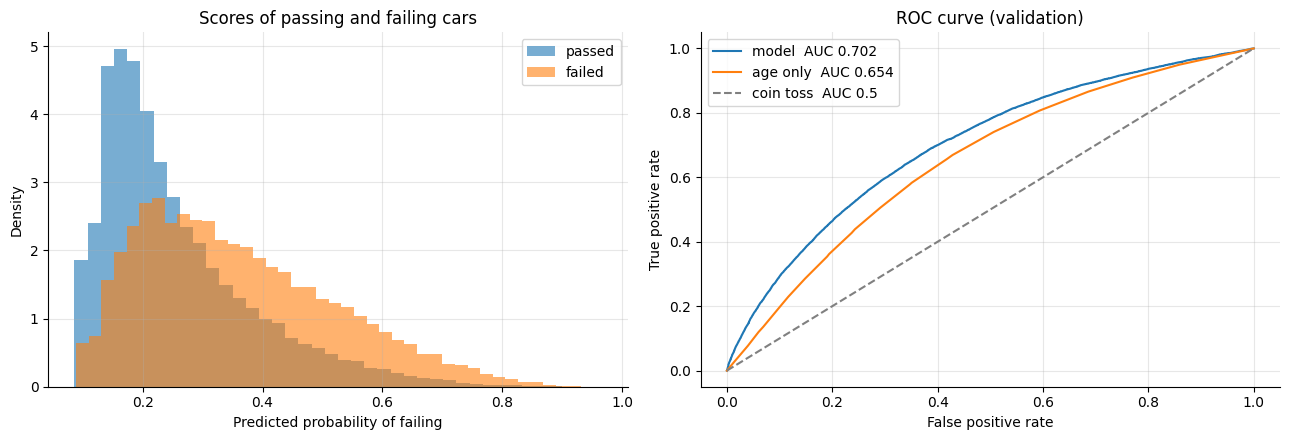

In [20]:
val["p"] = probability(val, model)
y_val = val["target_failed"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.hist(val.loc[y_val == 0, "p"], bins=40, alpha=0.6, density=True, label="passed")
a1.hist(val.loc[y_val == 1, "p"], bins=40, alpha=0.6, density=True, label="failed")
a1.set(xlabel="Predicted probability of failing", ylabel="Density", title="Scores of passing and failing cars"); a1.legend()

age_rates = train.groupby(train["age_years"].apply(age_key))["target_failed"].mean()
p_base = val["age_years"].apply(age_key).map(age_rates)
for name, p in [("model", val["p"]), ("age only", p_base)]:
    fpr, tpr, _ = roc_curve(y_val, p)
    a2.plot(fpr, tpr, label=f"{name}  AUC {roc_auc_score(y_val, p):.3f}")
a2.plot([0, 1], [0, 1], "--", color="grey", label="coin toss  AUC 0.5")
a2.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve (validation)"); a2.legend()
plt.tight_layout(); plt.show()

## 8. Calibration

Ranking isn't enough when you show people a percentage: when the model says 30%, about 30% of those cars should fail. Sort cars into 10 equal groups by predicted probability, and compare each group's average prediction with its actual fail rate.

The left panel shows the model **before and after** Platt scaling on the validation year. The right panel is the honest check: the test set, which played no part in fitting anything.

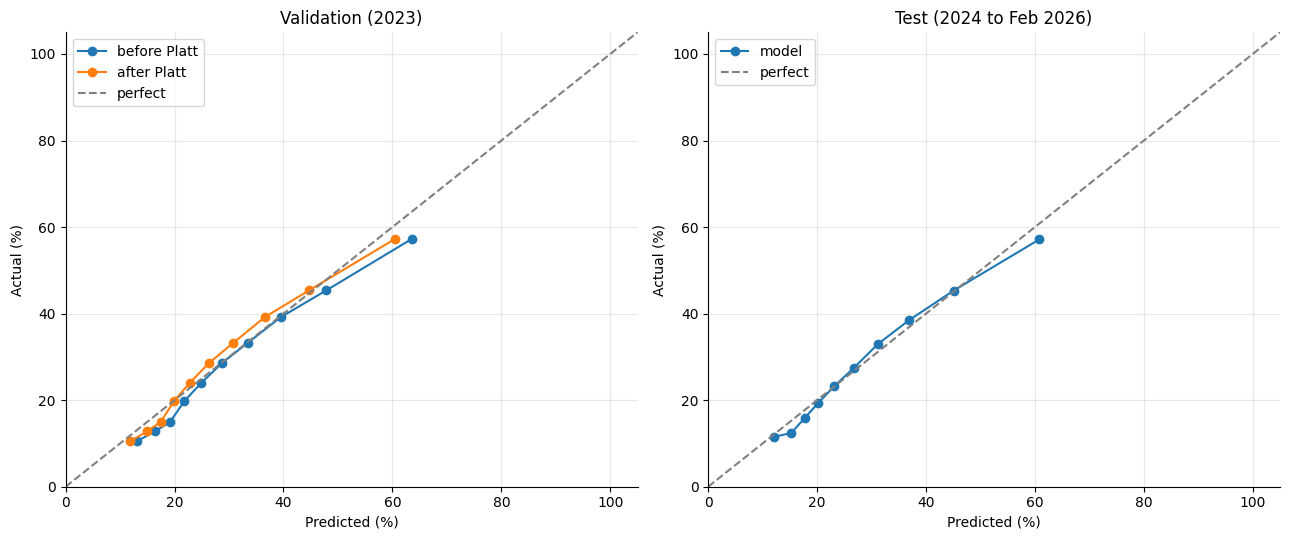

,predicted,actual,cars,gap_points
g,,,,
0,0.120,0.115,14180,0.532
1,0.153,0.124,14179,2.847
2,0.178,0.160,14179,1.822
3,0.203,0.194,14179,0.852
4,0.232,0.233,14179,-0.086
5,0.268,0.275,14179,-0.715
6,0.312,0.330,14179,-1.800
7,0.370,0.385,14179,-1.585
8,0.451,0.453,14179,-0.256


In [21]:
def deciles(p, y):
    g = pd.qcut(p, 10, labels=False, duplicates="drop")
    t = pd.DataFrame({"p": p, "y": y, "g": g}).groupby("g").agg(predicted=("p", "mean"), actual=("y", "mean"), cars=("y", "size"))
    t["gap_points"] = (t["predicted"] - t["actual"]) * 100
    return t

z_val = raw_logit(val, model)
raw_p = 1 / (1 + np.exp(-z_val))

test["p"] = probability(test, model)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, items, title in [(a1, [("before Platt", raw_p, y_val), ("after Platt", val["p"], y_val)], "Validation (2023)"),
                         (a2, [("model", test["p"], test["target_failed"])], "Test (2024 to Feb 2026)")]:
    for name, p, y in items:
        d = deciles(np.asarray(p), np.asarray(y))
        ax.plot(d["predicted"] * 100, d["actual"] * 100, marker="o", label=name)
    top = 5 * np.ceil(max(max(np.max(p), np.mean(y)) for _, p, y in items) * 100 / 5 + 1)
    ax.plot([0, top], [0, top], "--", color="grey", label="perfect")
    ax.set(xlim=(0, top), ylim=(0, top), xlabel="Predicted (%)", ylabel="Actual (%)", title=title); ax.legend()
plt.tight_layout(); plt.show()

deciles(test["p"].to_numpy(), test["target_failed"].to_numpy()).round(3)

**Try this:** each test decile holds about 14,000 cars, so its actual fail rate is uncertain by about ±0.8 points. Which deciles are off by more than that? That's genuine miscalibration rather than noise.

## 9. Risk bands

The site leads with a band, not the percentage: each car is compared with cars of its own age (below the 40th percentile is Lower risk, above the 80th is Higher risk). The bands must separate real fail rates.

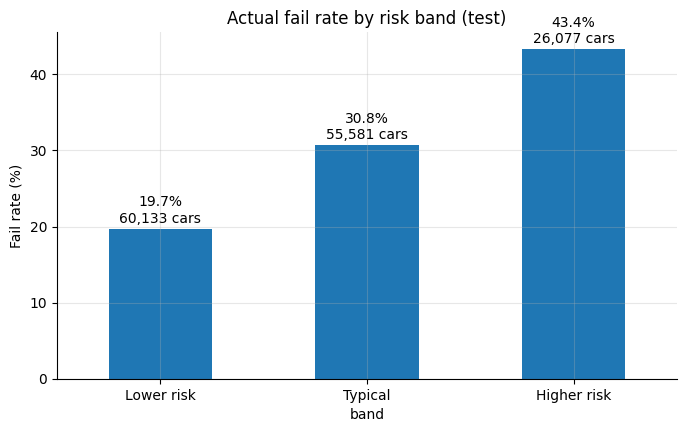

In [22]:
test["band"] = band(test, test["p"].to_numpy(), model)
order = ["Lower risk", "Typical", "Higher risk"]
b = test.groupby("band")["target_failed"].agg(["mean", "count"]).loc[order]
ax = (b["mean"] * 100).plot(kind="bar", rot=0, title="Actual fail rate by risk band (test)")
for i, (m, n) in enumerate(zip(b["mean"], b["count"])):
    ax.text(i, m * 100 + 0.8, f"{m*100:.1f}%\n{n:,} cars", ha="center")
ax.set_ylabel("Fail rate (%)"); plt.show()

## 10. Segments

A model can work well overall but badly for one group. Here's AUC by make on the test set. The validation gate was 0.58, the dashed line.

**Try this:** repeat it for `fuel_type`, and for first tests against cars with history.

/var/folders/nr/j3bb4py129n42mzntn2f26g80000gn/T/ipykernel_40866/4079028575.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auc_by_make = seg.groupby("make_seg").apply(lambda g: roc_auc_score(g["target_failed"], g["p"])


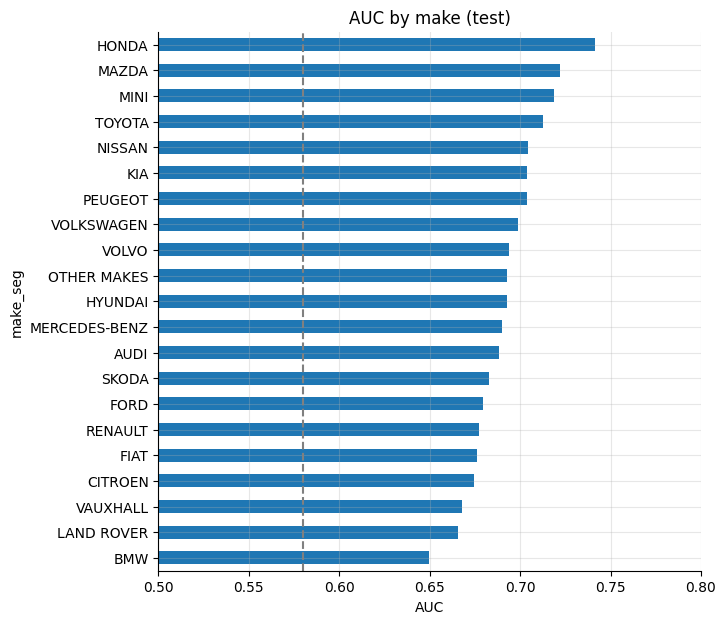

In [23]:
makes = set(model["preprocessing"]["makes"])
seg = test.assign(make_seg=test["make"].where(test["make"].isin(makes), "OTHER MAKES"))
auc_by_make = seg.groupby("make_seg").apply(lambda g: roc_auc_score(g["target_failed"], g["p"])
                                            if g["target_failed"].nunique() == 2 else np.nan).sort_values()
ax = auc_by_make.plot(kind="barh", figsize=(7, 7), title="AUC by make (test)")
ax.axvline(0.58, ls="--", color="grey"); ax.set_xlabel("AUC"); ax.set_xlim(0.5, 0.8); plt.show()

## 11. One car, end to end

This is exactly what the Worker does for one lookup, split into its pieces: the feature values, each column's **contribution** to the log-odds (coefficient × the transformed value), the sum, the calibration, and the band.

**Try this:** set `pick_row` to a different row, or edit one feature in `car`, for example add a prior fail, and see the probability move.

                             1
make             MERCEDES-BENZ
age_years                10.02
n_prior_fails              NaN
fails_last_3               NaN
prev_odometer              NaN
prev_fail_items            NaN
prev_advisories            NaN
days_since_prev            NaN
target_failed                0


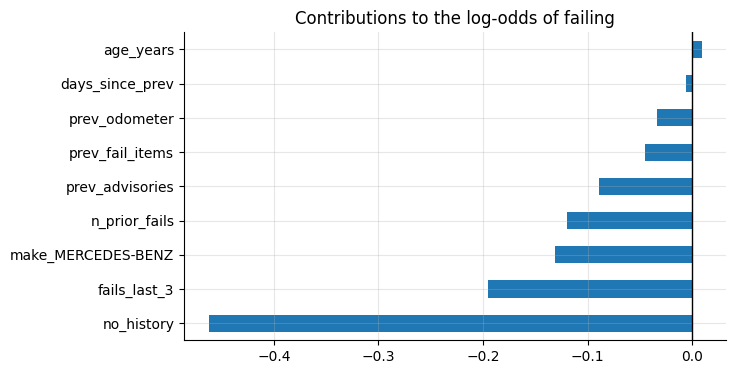

intercept -0.950 + contributions -1.073 = log-odds -2.023
calibrated probability = 1 / (1 + exp(-(0.990 x -2.023 -0.129))) = 10.6%
band: Lower risk   |   actual result: PASSED


In [29]:
pick_row = test.index[0]
car = test.loc[[pick_row]].copy()
# car.loc[pick_row, "n_prior_fails"] += 1        # <- uncomment to experiment

x = design_matrix(car, model)[0]
contrib = pd.Series(x * np.array(model["coefficients"]), index=model["columns"])
contrib = contrib[contrib.abs() > 1e-9].sort_values()

z = model["intercept"] + contrib.sum()
a, b_ = model["calibration"]["a"], model["calibration"]["b"]
p = 1 / (1 + np.exp(-(a * z + b_)))

print(car[["make", "age_years", "n_prior_fails", "fails_last_3", "prev_odometer",
           "prev_fail_items", "prev_advisories", "days_since_prev", "target_failed"]].T)
ax = contrib.plot(kind="barh", figsize=(7, 4), title="Contributions to the log-odds of failing")
ax.axvline(0, color="black", lw=1); plt.show()
print(f"intercept {model['intercept']:+.3f} + contributions {contrib.sum():+.3f} = log-odds {z:+.3f}")
print(f"calibrated probability = 1 / (1 + exp(-({a:.3f} x {z:+.3f} {b_:+.3f}))) = {p:.1%}")
print(f"band: {band(car, np.array([p]), model)[0]}   |   actual result: {'FAILED' if car['target_failed'].iloc[0] else 'PASSED'}")

## 12. Exercises

1. **Drop a feature.** Refit in stage 6 without `fails_last_3`: remove it from `NUMERIC` in a copy of the model's columns, refit, and compare the validation AUC. How much did it add?
2. **Lookup-table challenger.** Predict each validation car's probability as the training fail rate of its cell (age band × prior-fails bucket × last result). Plot its calibration next to the model's in stage 8. Which ranks better? Which calibrates better?
3. **Recalibrate on a different year.** Refit Platt's two parameters on 2022 instead of 2023, and see how the test calibration changes.
4. **Explain one result.** Find a car in the test set rated Higher risk that passed, and one rated Lower risk that failed. Use stage 11 to see why the model scored them as it did.

Keep these experiments in the notebook: the test set is for looking, never for choosing. Anything you'd change in the deployed model goes through validation first.